<a href="https://colab.research.google.com/github/shashikawka/Intelligent-Student-Performance-Analytics-and-Learning-Stratergy-Optimization/blob/main/step2b_outlier_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 2b - Outlier Analysis
### UCI Student Performance + xAPI Educational Dataset

**Three methods are applied — as covered in lecture slides (Han et al.):**

| Method | Type | When to use |
|--------|------|-------------|
| IQR + Boxplot | Statistical (non-parametric) | Data is skewed or non-normal |
| Z-score | Statistical (parametric) | Continuous columns, approx. normal |
| LOF | Proximity-based (density) | Detect multivariate / local outliers |

> Run each cell top to bottom with Shift+Enter.
> Place `student-mat.csv`, `student-por.csv`, `xAPI-Edu-Data.csv` in the same folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 1 - Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#EF9F27'
GRAY   = '#888780'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = 'white'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

In [ ]:
uci_math = pd.read_csv('/content/drive/MyDrive/A - PROJECT/student-mat.csv', sep=';')
uci_math['subject'] = 'Math'
uci_por  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/student-por.csv', sep=';')
uci_por['subject']  = 'Portuguese'
uci  = pd.concat([uci_math, uci_por], ignore_index=True)
xapi = pd.read_csv('/content/drive/MyDrive/A - PROJECT/xAPI-Edu-Data.csv')

# Numeric columns we will run outlier detection on
UCI_NUM  = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences',
            'G1','G2','G3']
XAPI_NUM = ['raisedhands','VisITedResources','AnnouncementsView','Discussion']

print('UCI rows :', len(uci))
print('xAPI rows:', len(xapi))

UCI rows : 1044
xAPI rows: 480


---
## Method 1 — IQR (Interquartile Range)

**What it is:** A non-parametric statistical method.
Flags any value below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR` as an outlier.

**Why we use it here:**
The UCI and xAPI datasets contain mixed distributions — skewed columns (absences),
zero-inflated columns (failures), and bounded ordinal scales (studytime 1–4).
IQR does **not assume normality**, making it suitable for all column types.
It is also the method explicitly demonstrated in Chapter 2 of Han et al.
(boxplot with 1.5×IQR fences) — the textbook used in this course.

**Limitation:** Produces false positives on ordinal/bounded columns
because most values cluster at one end, causing IQR to collapse toward zero.

In [ ]:
# ── WHY IQR ──────────────────────────────────────────────────────────────────
# IQR is chosen as the first method because:
# 1. It is non-parametric — no assumption about the distribution shape
# 2. Educational data is often skewed (most students pass, few fail badly)
# 3. It is the standard method shown in Chapter 2 of Han et al. textbook
# 4. Easy to visualise with boxplots — useful for the paper
# ─────────────────────────────────────────────────────────────────────────────

def iqr_outliers(df, col):
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (df[col] < lower) | (df[col] > upper)
    return mask, round(lower, 2), round(upper, 2)


In [ ]:
# Run IQR on all UCI numeric columns and print results
print('UCI — IQR Outlier Report')
print(f'{"Column":<14} {"Lower fence":>12} {"Upper fence":>12} '
      f'{"Min":>6} {"Max":>6} {"Flagged":>8} {"Pct":>6}')
print('-' * 70)

uci_iqr_results = {}
for col in UCI_NUM:
    mask, lo, hi = iqr_outliers(uci, col)
    n   = mask.sum()
    pct = round(n / len(uci) * 100, 1)
    uci_iqr_results[col] = mask
    flag = ' ***' if n > 0 else ''
    print(f'{col:<14} {lo:>12} {hi:>12} '
          f'{uci[col].min():>6} {uci[col].max():>6} {n:>8} {pct:>5}%{flag}')

print()

UCI — IQR Outlier Report
Column          Lower fence  Upper fence    Min    Max  Flagged    Pct
----------------------------------------------------------------------
age                    13.0         21.0     15     22        2   0.2% ***
Medu                   -1.0          7.0      0      4        0   0.0%
Fedu                   -2.0          6.0      0      4        0   0.0%
traveltime             -0.5          3.5      1      4       24   2.3% ***
studytime              -0.5          3.5      1      4       62   5.9% ***
failures                0.0          0.0      0      3      183  17.5% ***
famrel                  2.5          6.5      1      5       77   7.4% ***
freetime                1.5          5.5      1      5       64   6.1% ***
goout                  -1.0          7.0      1      5        0   0.0%
Dalc                   -0.5          3.5      1      5       52   5.0% ***
Walc                   -2.0          6.0      1      5        0   0.0%
health                  

In [ ]:
# Run IQR on all xAPI numeric columns
print('xAPI — IQR Outlier Report')
print(f'{"Column":<24} {"Lower fence":>12} {"Upper fence":>12} '
      f'{"Min":>6} {"Max":>6} {"Flagged":>8}')
print('-' * 72)

xapi_iqr_results = {}
for col in XAPI_NUM:
    mask, lo, hi = iqr_outliers(xapi, col)
    n = mask.sum()
    xapi_iqr_results[col] = mask
    print(f'{col:<24} {lo:>12} {hi:>12} '
          f'{xapi[col].min():>6} {xapi[col].max():>6} {n:>8}')

print()
print('Result: Zero outliers detected in xAPI by IQR method.')

xAPI — IQR Outlier Report
Column                    Lower fence  Upper fence    Min    Max  Flagged
------------------------------------------------------------------------
raisedhands                    -73.12       163.88      0    100        0
VisITedResources                -76.0        180.0      0     99        0
AnnouncementsView               -52.0        124.0      0     98        0
Discussion                      -55.0        145.0      1     99        0

Result: Zero outliers detected in xAPI by IQR method.


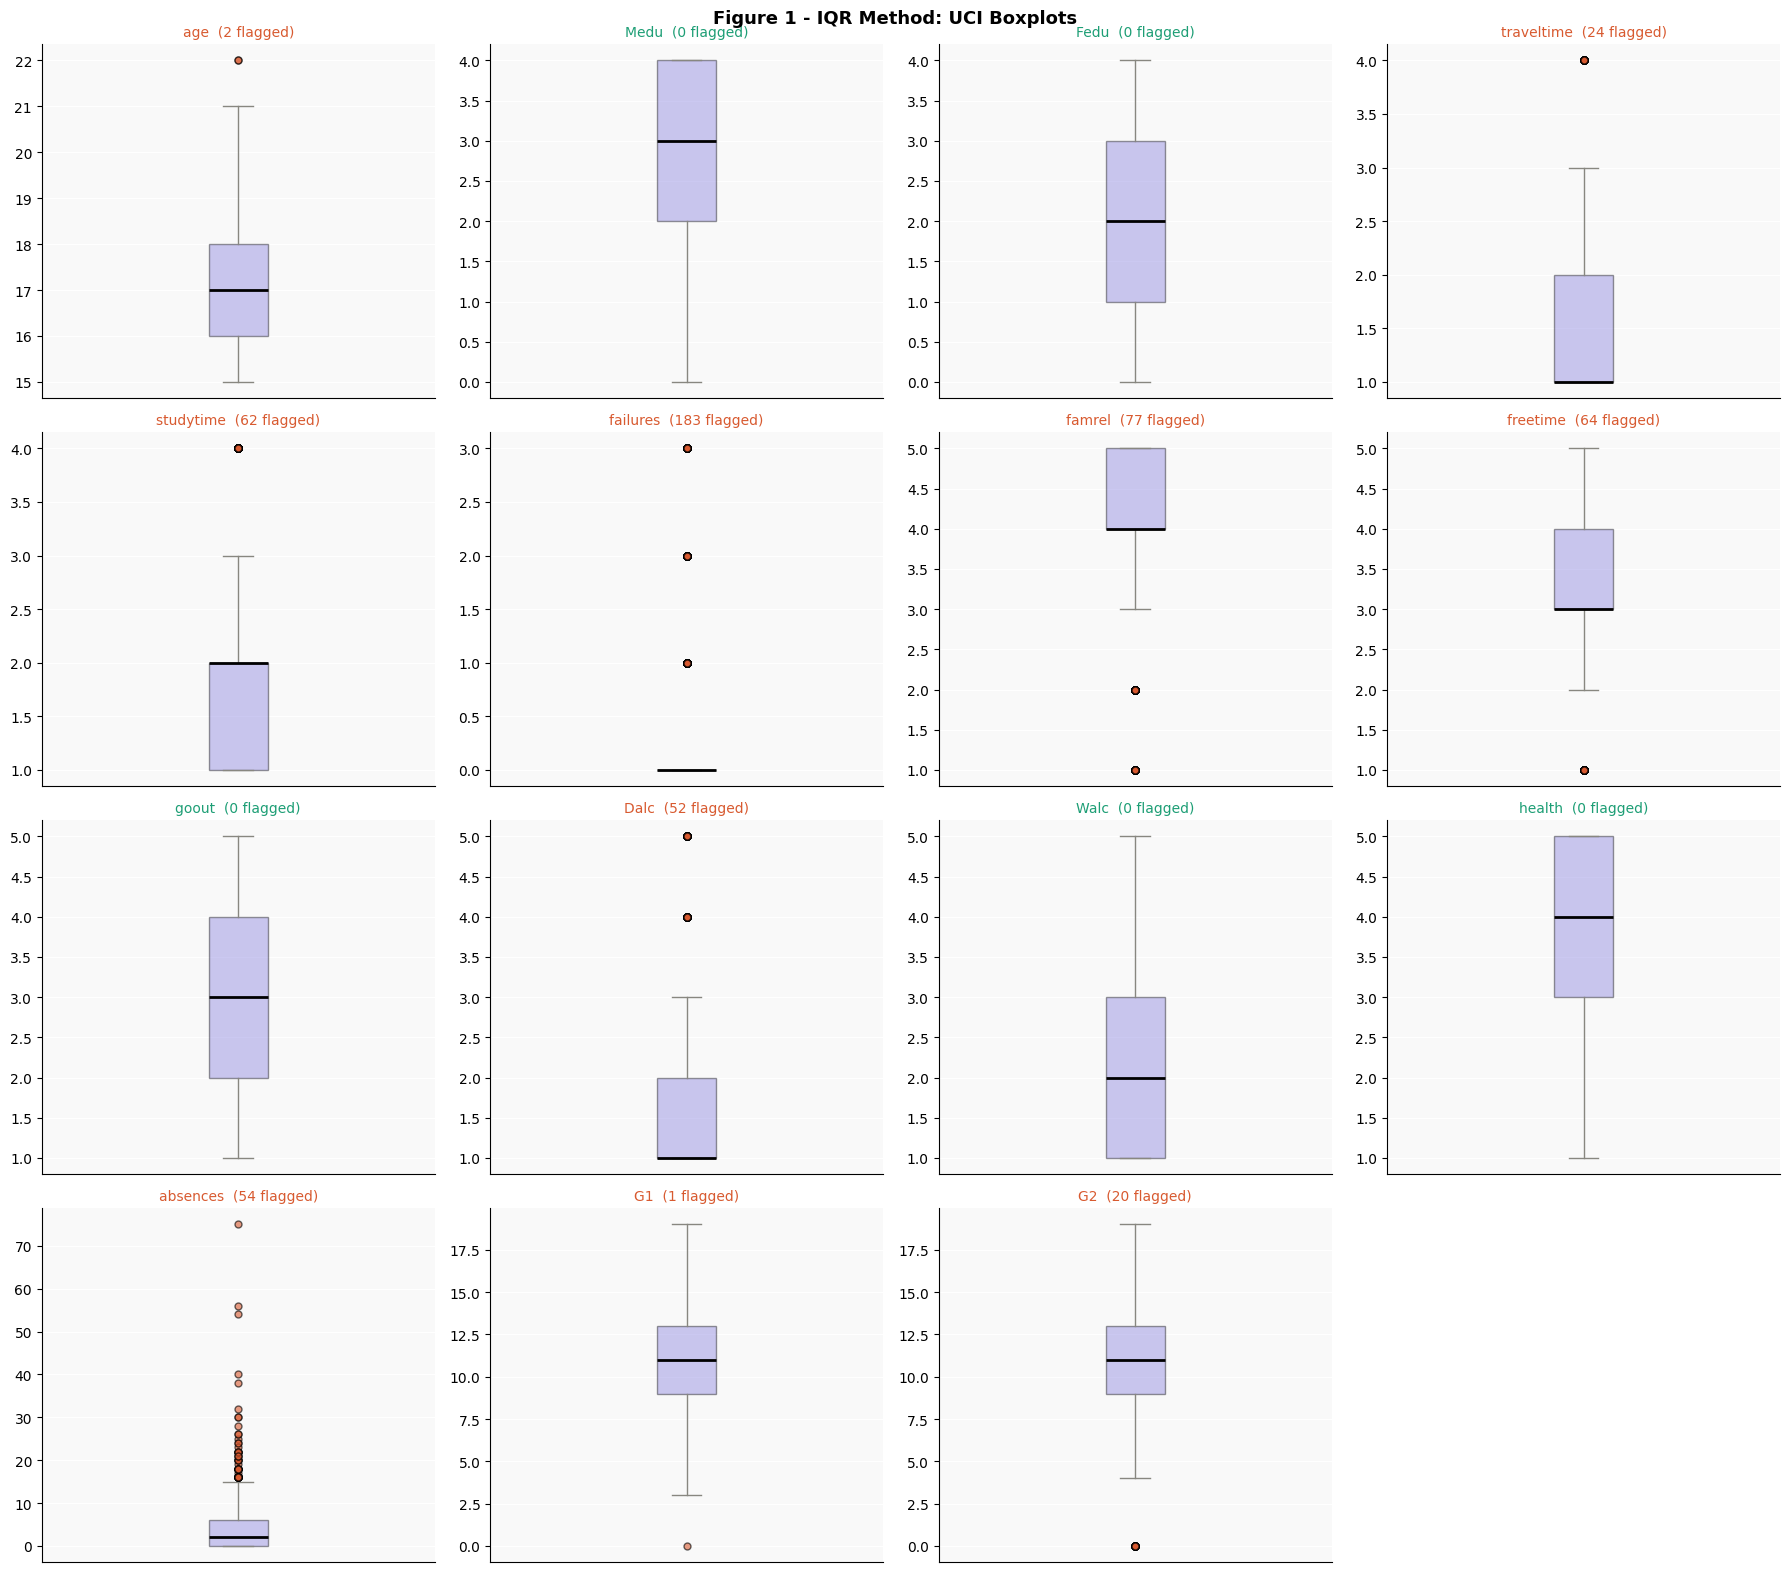

In [ ]:
# Figure 1: Boxplots for all UCI numeric columns
# Each dot beyond the whiskers is a flagged outlier
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle('Figure 1 - IQR Method: UCI Boxplots',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, UCI_NUM):
    mask, lo, hi = iqr_outliers(uci, col)
    n = mask.sum()
    ax.boxplot(uci[col].dropna(), patch_artist=True,
               flierprops=dict(marker='o', markerfacecolor=CORAL,
                               markersize=5, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=PURPLE, alpha=0.4),
               whiskerprops=dict(color=GRAY),
               capprops=dict(color=GRAY))
    title_color = CORAL if n > 0 else TEAL
    ax.set_title(f'{col}  ({n} flagged)', fontsize=10, color=title_color)
    ax.set_xticks([])

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig1_iqr_boxplots_uci.png', dpi=150, bbox_inches='tight')
plt.show()

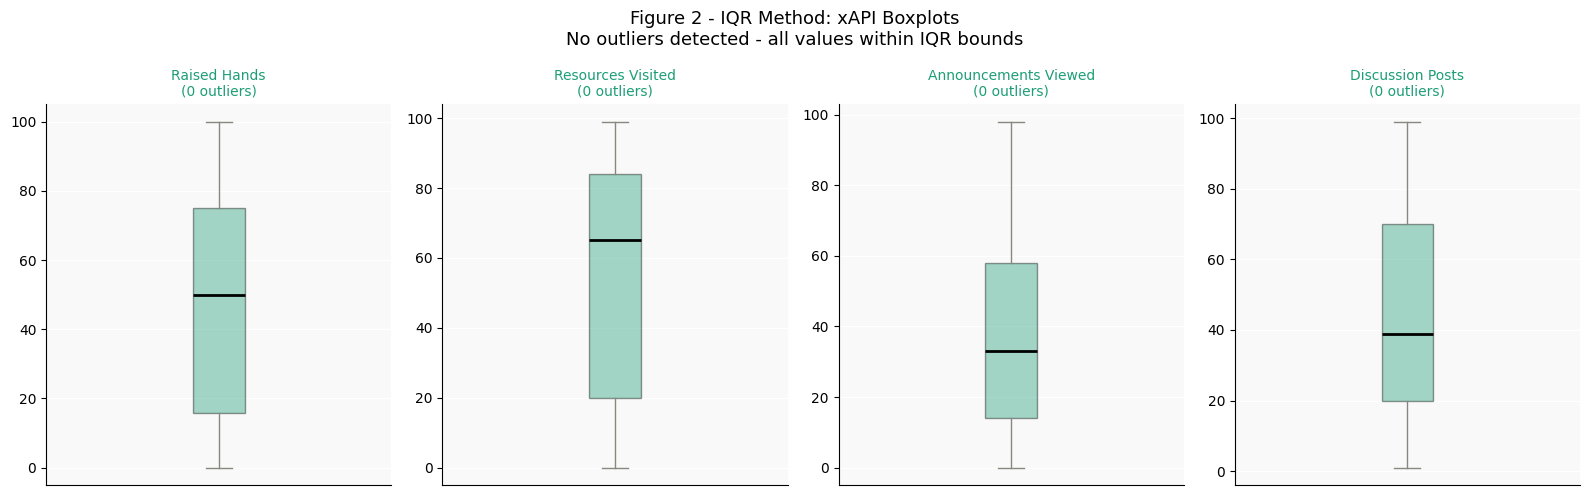

In [ ]:
# Figure 2: Boxplots for xAPI numeric columns
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Figure 2 - IQR Method: xAPI Boxplots\n'
             'No outliers detected - all values within IQR bounds',
             fontsize=13)

labels = ['Raised Hands','Resources Visited','Announcements Viewed','Discussion Posts']
for ax, col, label in zip(axes, XAPI_NUM, labels):
    ax.boxplot(xapi[col], patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=TEAL, alpha=0.4),
               whiskerprops=dict(color=GRAY),
               capprops=dict(color=GRAY),
               flierprops=dict(marker='o', markerfacecolor=CORAL,
                               markersize=5, alpha=0.6))
    ax.set_title(label + '\n(0 outliers)', fontsize=10, color=TEAL)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig2_iqr_boxplots_xapi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Method 2 — Z-score (Parametric Statistical Method)

**What it is:** Measures how many standard deviations a value is from the mean.
Formula: `z = (x - mean) / std_dev`
A point is flagged as an outlier if `|z| > 3`.

**Why we use it here:**
Z-score is applied as a **complementary parametric method** to cross-validate
the IQR findings on continuous grade columns (G1, G2, G3, absences).
The merged dataset (n=1044 students) approximates normality by the
Central Limit Theorem, making parametric methods more appropriate here.
Consistency between IQR and Z-score strengthens any outlier decision.
This method is explicitly covered in your lecture slides
(Han et al. Chapter 12 — Grubbs test / maximum normed residual test).

**Note on Grubbs vs Z-score:**
Both use the same formula `z = (x - mean) / std_dev`.
Grubbs test is the formal statistical version where the threshold is
calculated from the t-distribution based on sample size N and α.
Z-score uses the simpler fixed threshold of |z| > 3.
For n=1044 the difference is negligible — we apply Z-score here.

In [ ]:
# ── WHY Z-SCORE ──────────────────────────────────────────────────────────────
# Z-score is chosen as the second method because:
# 1. It is the parametric statistical method shown in lecture slides
#    (Han et al. Chapter 12 — Grubbs test uses the same z = (x-mean)/std formula)
# 2. Continuous columns (G1, G2, G3, absences) are approx. normal for n=1044
# 3. Using Z-score alongside IQR cross-validates our findings:
#    if BOTH flag the same point, the outlier claim is much stronger
# 4. Threshold |z| > 3 covers 99.7% of data under a normal distribution
#    — any point beyond this is statistically very unlikely to be normal
# ─────────────────────────────────────────────────────────────────────────────

def zscore_outliers(df, col, threshold=3):
    z     = np.abs(stats.zscore(df[col].dropna()))
    # Rebuild mask aligned to original dataframe index
    z_series = pd.Series(z, index=df[col].dropna().index)
    mask  = z_series > threshold
    # Reindex to full dataframe (missing values treated as non-outliers)
    mask  = mask.reindex(df.index, fill_value=False)
    return mask

print('Z-score outlier function defined.')
print('Threshold: |z| > 3  (value is more than 3 std deviations from the mean)')

Z-score outlier function defined.
Threshold: |z| > 3  (value is more than 3 std deviations from the mean)


In [ ]:
# Run Z-score on all UCI numeric columns
print('UCI — Z-score Outlier Report  (threshold |z| > 3)')
print(f'{"Column":<14} {"Mean":>8} {"Std":>8} {"Flagged":>9} {"Pct":>6}')
print('-' * 50)

uci_zscore_results = {}
for col in UCI_NUM:
    mask = zscore_outliers(uci, col)
    n    = mask.sum()
    pct  = round(n / len(uci) * 100, 1)
    uci_zscore_results[col] = mask
    flag = ' ***' if n > 0 else ''
    print(f'{col:<14} {uci[col].mean():>8.2f} {uci[col].std():>8.2f} '
          f'{n:>9} {pct:>5}%{flag}')

print()

UCI — Z-score Outlier Report  (threshold |z| > 3)
Column             Mean      Std   Flagged    Pct
--------------------------------------------------
age               16.73     1.24         5   0.5% ***
Medu               2.60     1.12         0   0.0%
Fedu               2.39     1.10         0   0.0%
traveltime         1.52     0.73        24   2.3% ***
studytime          1.97     0.83         0   0.0%
failures           0.26     0.66        30   2.9% ***
famrel             3.94     0.93        30   2.9% ***
freetime           3.20     1.03         0   0.0%
goout              3.16     1.15         0   0.0%
Dalc               1.49     0.91        26   2.5% ***
Walc               2.28     1.29         0   0.0%
health             3.54     1.42         0   0.0%
absences           4.43     6.21        14   1.3% ***
G1                11.21     2.98         1   0.1% ***
G2                11.25     3.29        20   1.9% ***
G3                11.34     3.86         0   0.0%



In [ ]:
# Run Z-score on xAPI numeric columns
print('xAPI — Z-score Outlier Report  (threshold |z| > 3)')
print(f'{"Column":<24} {"Mean":>8} {"Std":>8} {"Flagged":>9}')
print('-' * 55)

xapi_zscore_results = {}
for col in XAPI_NUM:
    mask = zscore_outliers(xapi, col)
    n    = mask.sum()
    xapi_zscore_results[col] = mask
    print(f'{col:<24} {xapi[col].mean():>8.2f} {xapi[col].std():>8.2f} {n:>9}')

print()
print('Result: Zero outliers detected in xAPI by Z-score method.')

xAPI — Z-score Outlier Report  (threshold |z| > 3)
Column                       Mean      Std   Flagged
-------------------------------------------------------
raisedhands                 46.77    30.78         0
VisITedResources            54.80    33.08         0
AnnouncementsView           37.92    26.61         0
Discussion                  43.28    27.64         0

Result: Zero outliers detected in xAPI by Z-score method.


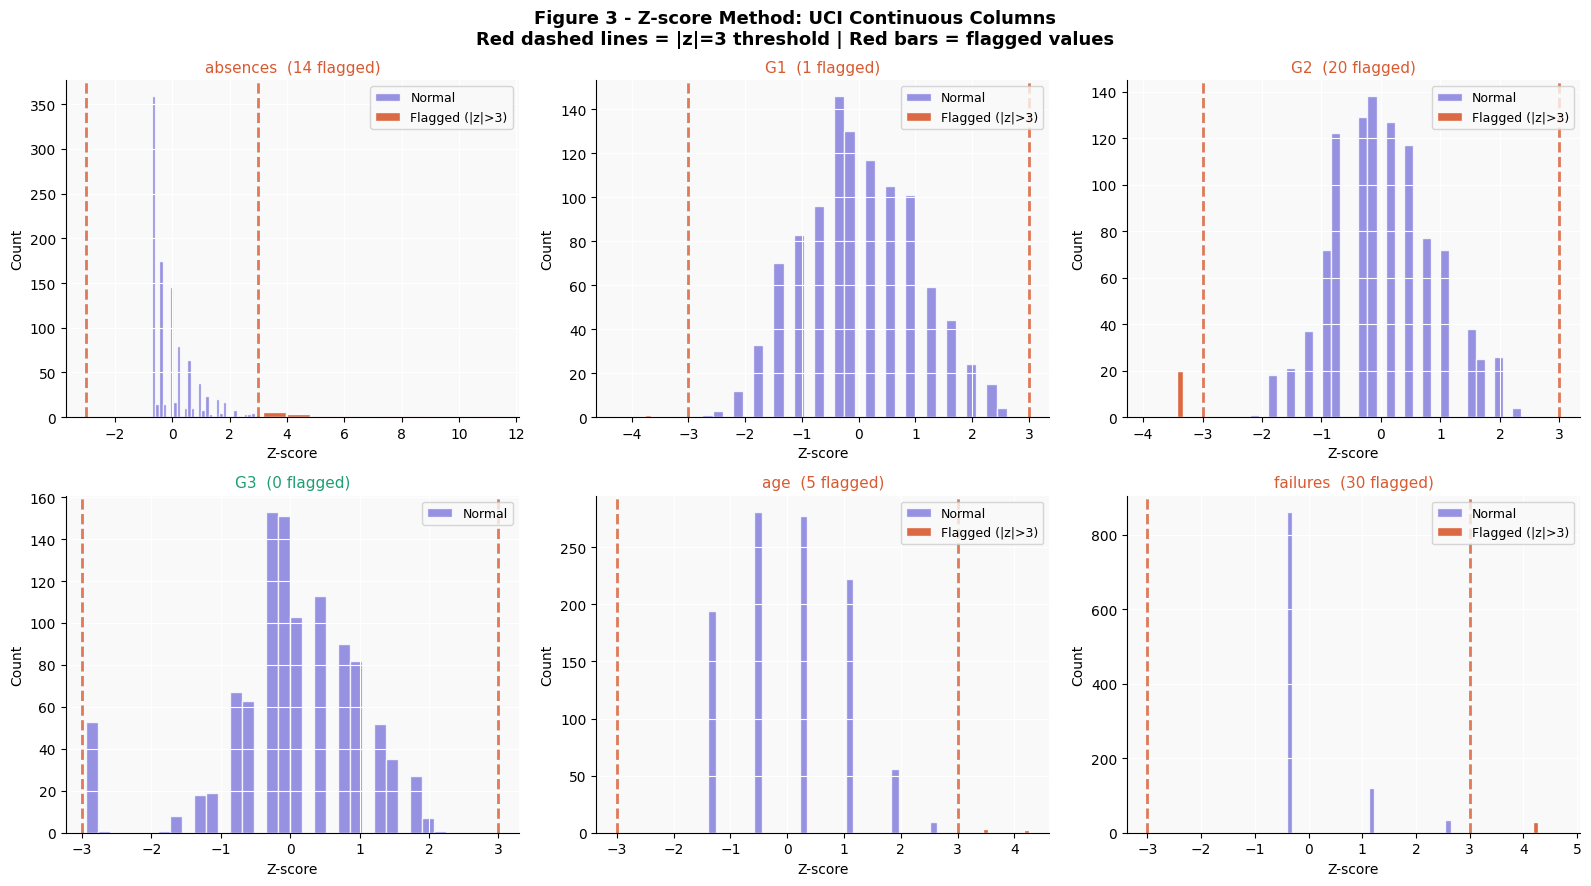

In [ ]:
# Figure 3: Z-score distribution for continuous UCI columns
# Shows where the |z| > 3 threshold cuts off
continuous_cols = ['absences', 'G1', 'G2', 'G3', 'age', 'failures']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figure 3 - Z-score Method: UCI Continuous Columns\n'
             'Red dashed lines = |z|=3 threshold | Red bars = flagged values',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, continuous_cols):
    z_vals = stats.zscore(uci[col].dropna())
    mask_z = np.abs(z_vals) > 3

    # Plot histogram of z-scores
    ax.hist(z_vals[~mask_z], bins=30, color=PURPLE,
            edgecolor='white', alpha=0.8, label='Normal')
    if mask_z.sum() > 0:
        ax.hist(z_vals[mask_z], bins=10, color=CORAL,
                edgecolor='white', alpha=0.9, label='Flagged (|z|>3)')

    # Draw threshold lines
    ax.axvline( 3, color=CORAL, linewidth=2, linestyle='--', alpha=0.8)
    ax.axvline(-3, color=CORAL, linewidth=2, linestyle='--', alpha=0.8)

    n_flag = mask_z.sum()
    ax.set_title(f'{col}  ({n_flag} flagged)',
                 fontsize=11,
                 color=CORAL if n_flag > 0 else TEAL)
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig3_zscore_uci.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Method 3 — LOF (Local Outlier Factor)

**What it is:** A density-based proximity method.
For each point, LOF compares its local density to the density of its k nearest neighbours.
A point with much lower density than its neighbours gets a high LOF score → outlier.

**Why we use it here:**
IQR and Z-score detect outliers **one column at a time** (univariate).
But a student may look normal on every individual feature yet be anomalous
when you consider **all features together** — for example, a student with
very high absences AND very high grades is unusual even though neither
value alone triggers a flag.
LOF catches these **multivariate outliers** that the first two methods miss.
This method is explicitly covered in your lecture slides
(Han et al. — Proximity-Based Methods, Density-Based Outlier Detection).

**LOF score interpretation:**
- LOF ≈ 1.0 → point has similar density to neighbours → normal
- LOF >> 1.0 → point is much less dense than neighbours → outlier
- We use LOF > 1.5 as our threshold (common choice for educational data)

In [ ]:
# ── WHY LOF ──────────────────────────────────────────────────────────────────
# LOF is chosen as the third method because:
# 1. It is the density-based proximity method covered in lecture slides
#    (Han et al. Chapter 12 — Local Outlier Factor)
# 2. IQR and Z-score are univariate — they check one column at a time
#    LOF checks ALL numeric columns simultaneously (multivariate)
# 3. A student may appear normal on each feature individually
#    but be anomalous in the combined feature space
#    Example: high absences + high grades = unusual combination
# 4. LOF is robust — it adapts to local density, so it works well
#    even when outliers cluster in different regions of the data
# Parameter choice: n_neighbors=20 is standard for datasets of ~1000 rows
# Threshold: LOF score > 1.5 flags a point as an outlier
# ─────────────────────────────────────────────────────────────────────────────

# Prepare UCI numeric data for LOF
# We scale first — LOF uses distances so all features must be on the same scale
uci_num_data = uci[UCI_NUM].copy()
uci_scaled   = StandardScaler().fit_transform(uci_num_data)

# Fit LOF
# n_neighbors=20: each point is compared to its 20 nearest neighbours
# novelty=False: we are detecting outliers in the training data itself
lof_uci = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof_uci.fit_predict(uci_scaled)

# Get the LOF scores (negative_outlier_factor_ — we negate it to get positive scores)
lof_scores_uci = -lof_uci.negative_outlier_factor_

# Flag as outlier if LOF score > 1.5
LOF_THRESHOLD = 1.5
uci_lof_mask  = lof_scores_uci > LOF_THRESHOLD

print('UCI — LOF Outlier Detection')
print(f'  n_neighbors : 20')
print(f'  Threshold   : LOF score > {LOF_THRESHOLD}')
print(f'  Total rows  : {len(uci)}')
print(f'  Flagged     : {uci_lof_mask.sum()} rows ({round(uci_lof_mask.mean()*100,1)}%)')
print(f'  LOF score range: {lof_scores_uci.min():.2f} to {lof_scores_uci.max():.2f}')

UCI — LOF Outlier Detection
  n_neighbors : 20
  Threshold   : LOF score > 1.5
  Total rows  : 1044
  Flagged     : 6 rows (0.6%)
  LOF score range: 0.96 to 2.20


In [ ]:
# Prepare xAPI numeric data for LOF
xapi_num_data = xapi[XAPI_NUM].copy()
xapi_scaled   = StandardScaler().fit_transform(xapi_num_data)

lof_xapi = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof_xapi.fit_predict(xapi_scaled)
lof_scores_xapi = -lof_xapi.negative_outlier_factor_
xapi_lof_mask   = lof_scores_xapi > LOF_THRESHOLD

print('xAPI — LOF Outlier Detection')
print(f'  n_neighbors : 20')
print(f'  Threshold   : LOF score > {LOF_THRESHOLD}')
print(f'  Total rows  : {len(xapi)}')
print(f'  Flagged     : {xapi_lof_mask.sum()} rows ({round(xapi_lof_mask.mean()*100,1)}%)')
print(f'  LOF score range: {lof_scores_xapi.min():.2f} to {lof_scores_xapi.max():.2f}')

xAPI — LOF Outlier Detection
  n_neighbors : 20
  Threshold   : LOF score > 1.5
  Total rows  : 480
  Flagged     : 3 rows (0.6%)
  LOF score range: 0.94 to 1.60


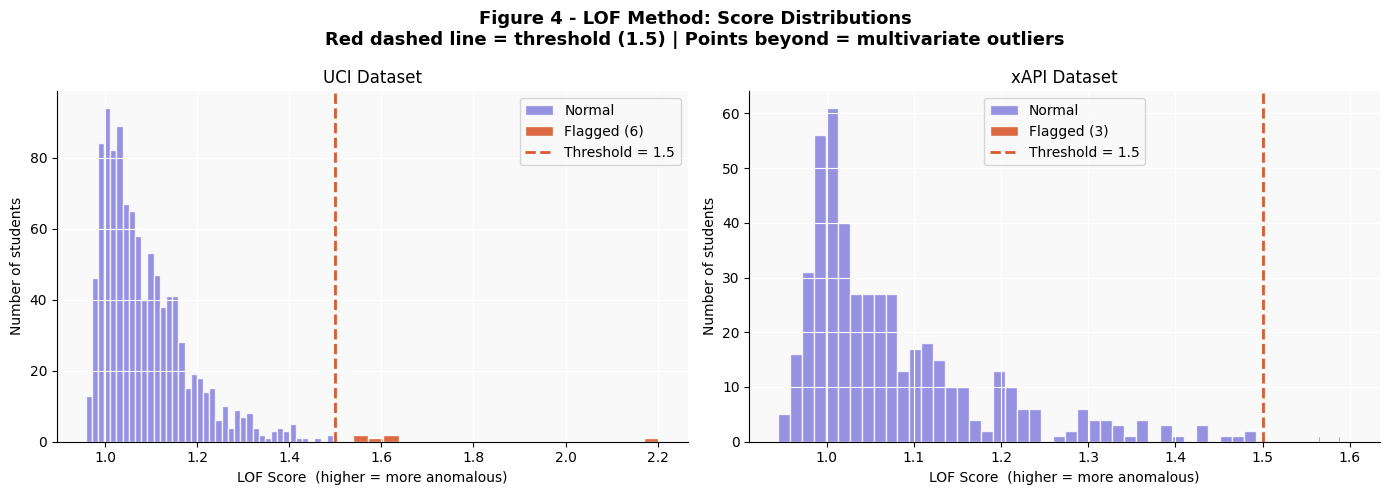

In [ ]:
# Figure 4: LOF score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4 - LOF Method: Score Distributions\n'
             'Red dashed line = threshold (1.5) | Points beyond = multivariate outliers',
             fontsize=13, fontweight='bold')

for ax, scores, mask, title, n_rows in zip(
        axes,
        [lof_scores_uci,  lof_scores_xapi],
        [uci_lof_mask,    xapi_lof_mask],
        ['UCI Dataset',   'xAPI Dataset'],
        [len(uci),        len(xapi)]):

    ax.hist(scores[~mask], bins=40, color=PURPLE,
            edgecolor='white', alpha=0.8, label='Normal')
    if mask.sum() > 0:
        ax.hist(scores[mask], bins=20, color=CORAL,
                edgecolor='white', alpha=0.9, label=f'Flagged ({mask.sum()})')
    ax.axvline(LOF_THRESHOLD, color=CORAL, linewidth=2,
               linestyle='--', label=f'Threshold = {LOF_THRESHOLD}')
    ax.set_title(title)
    ax.set_xlabel('LOF Score  (higher = more anomalous)')
    ax.set_ylabel('Number of students')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig4_lof_scores.png', dpi=150, bbox_inches='tight')
plt.show()

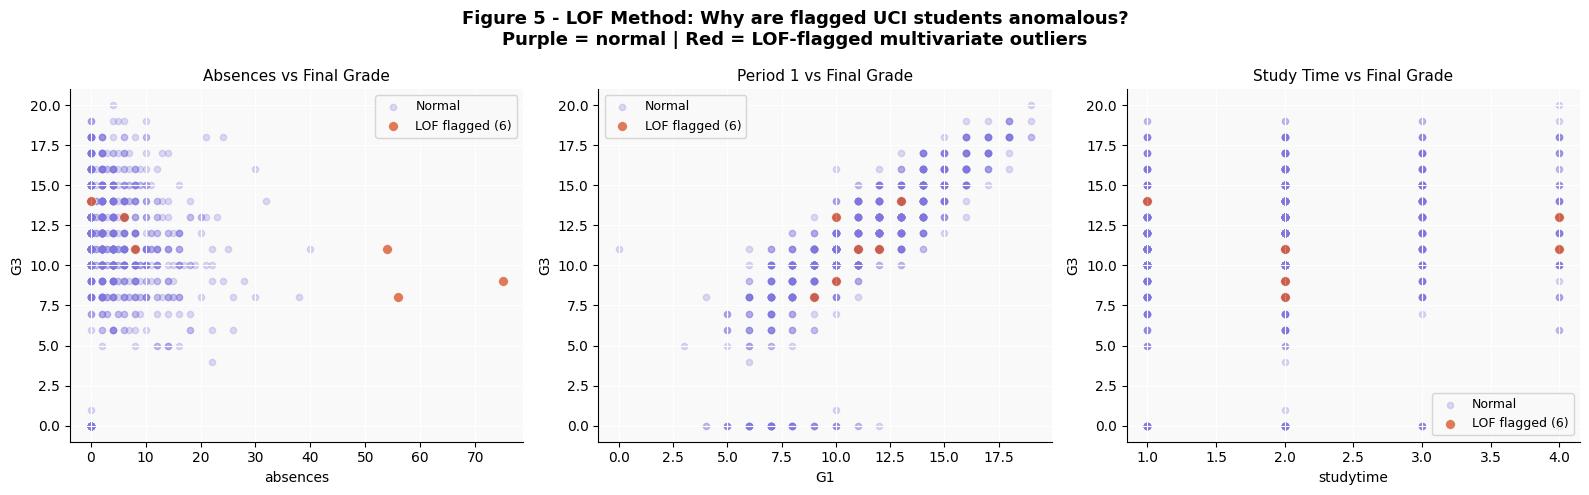

In [ ]:
# Figure 5: What makes LOF-flagged UCI students unusual?
# Plot the most informative feature pairs to show why they are anomalous
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 5 - LOF Method: Why are flagged UCI students anomalous?\n'
             'Purple = normal | Red = LOF-flagged multivariate outliers',
             fontsize=13, fontweight='bold')

feature_pairs = [
    ('absences', 'G3',  'Absences vs Final Grade'),
    ('G1',       'G3',  'Period 1 vs Final Grade'),
    ('studytime','G3',  'Study Time vs Final Grade'),
]

for ax, (fx, fy, title) in zip(axes, feature_pairs):
    # Normal points
    ax.scatter(uci.loc[~uci_lof_mask, fx],
               uci.loc[~uci_lof_mask, fy],
               alpha=0.25, color=PURPLE, s=20, label='Normal')
    # LOF-flagged points
    ax.scatter(uci.loc[uci_lof_mask, fx],
               uci.loc[uci_lof_mask, fy],
               alpha=0.8, color=CORAL, s=50,
               edgecolors='white', linewidth=0.5,
               label=f'LOF flagged ({uci_lof_mask.sum()})', zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig5_lof_scatter_uci.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 - Comparing All Three Methods

A key principle in outlier detection:
**if multiple methods agree on the same point, the outlier claim is stronger.**

Here we check how much overlap there is between IQR, Z-score, and LOF findings.

In [ ]:
# Build a summary dataframe showing which method flagged which UCI row
# We combine IQR flags across all columns (any column flagged = True)
uci_iqr_any    = pd.Series(
    np.any([uci_iqr_results[c].values for c in UCI_NUM], axis=0),
    index=uci.index)

uci_zscore_any = pd.Series(
    np.any([uci_zscore_results[c].values for c in UCI_NUM], axis=0),
    index=uci.index)

uci_lof_series = pd.Series(uci_lof_mask, index=uci.index)

comparison = pd.DataFrame({
    'IQR_flagged'    : uci_iqr_any,
    'ZScore_flagged' : uci_zscore_any,
    'LOF_flagged'    : uci_lof_series,
})

# How many rows flagged by each method
print('UCI — Flagged counts per method:')
print(f'  IQR    : {comparison["IQR_flagged"].sum()} rows')
print(f'  Z-score: {comparison["ZScore_flagged"].sum()} rows')
print(f'  LOF    : {comparison["LOF_flagged"].sum()} rows')
print()

# Rows flagged by ALL three methods — strongest outlier signal
all_three = comparison.all(axis=1)
print(f'Flagged by ALL 3 methods : {all_three.sum()} rows <- strongest signal')

# Rows flagged by exactly two methods
two_methods = comparison.sum(axis=1) == 2
print(f'Flagged by exactly 2     : {two_methods.sum()} rows')

# Rows flagged by only one method
one_method = comparison.sum(axis=1) == 1
print(f'Flagged by only 1        : {one_method.sum()} rows')

UCI — Flagged counts per method:
  IQR    : 418 rows
  Z-score: 127 rows
  LOF    : 6 rows

Flagged by ALL 3 methods : 6 rows <- strongest signal
Flagged by exactly 2     : 121 rows
Flagged by only 1        : 291 rows


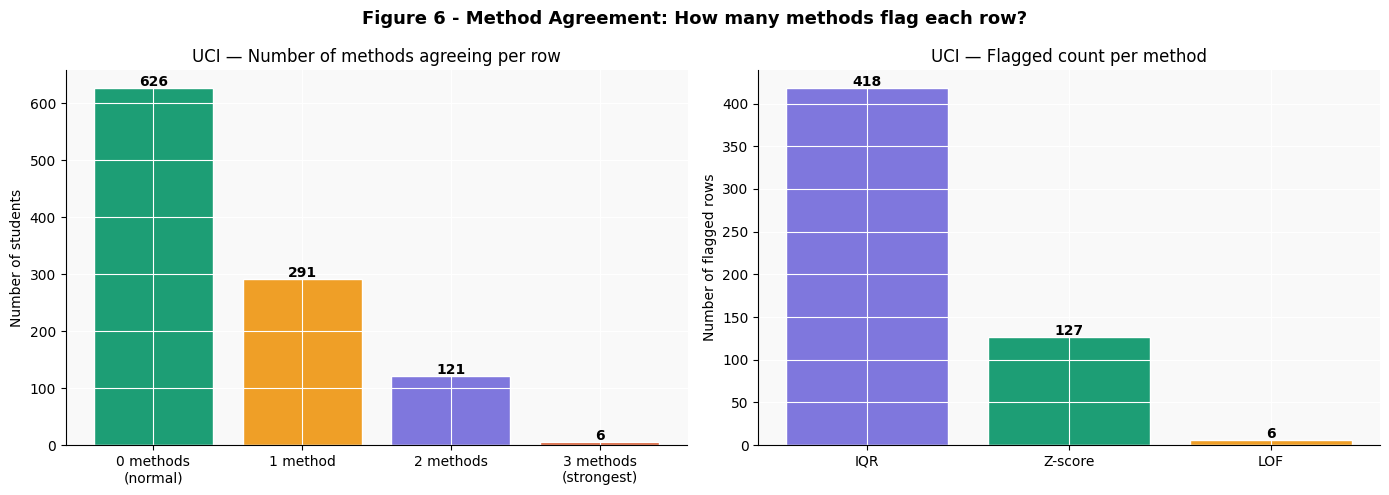

In [ ]:
# Figure 6: Venn-style bar chart showing method agreement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 6 - Method Agreement: How many methods flag each row?',
             fontsize=13, fontweight='bold')

# Left: stacked bar — count flagged by 0, 1, 2, 3 methods
agreement_counts = comparison.sum(axis=1).value_counts().sort_index()
colors_bar = [TEAL, AMBER, PURPLE, CORAL]
bars = axes[0].bar(
    ['0 methods\n(normal)', '1 method', '2 methods', '3 methods\n(strongest)'],
    [agreement_counts.get(i, 0) for i in range(4)],
    color=colors_bar, edgecolor='white')
for bar, val in zip(bars, [agreement_counts.get(i, 0) for i in range(4)]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('UCI — Number of methods agreeing per row')
axes[0].set_ylabel('Number of students')

# Right: per-method flagged count comparison
method_counts = [
    comparison['IQR_flagged'].sum(),
    comparison['ZScore_flagged'].sum(),
    comparison['LOF_flagged'].sum()
]
bars2 = axes[1].bar(['IQR', 'Z-score', 'LOF'],
                    method_counts,
                    color=[PURPLE, TEAL, AMBER], edgecolor='white')
for bar, val in zip(bars2, method_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('UCI — Flagged count per method')
axes[1].set_ylabel('Number of flagged rows')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig6_method_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

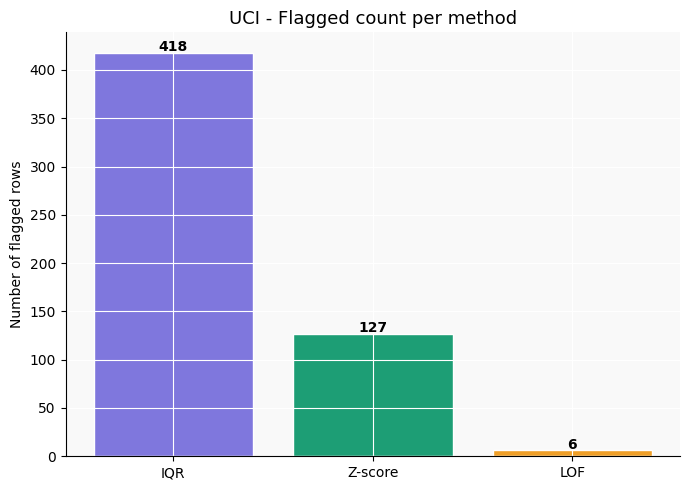

In [ ]:
# Figure 6 (Right only): per-method flagged count comparison
plt.figure(figsize=(7, 5))
plt.title('UCI - Flagged count per method',
          fontsize=13 )

method_counts = [
    comparison['IQR_flagged'].sum(),
    comparison['ZScore_flagged'].sum(),
    comparison['LOF_flagged'].sum()
]

bars = plt.bar(['IQR', 'Z-score', 'LOF'],
               method_counts,
               color=[PURPLE, TEAL, AMBER],
               edgecolor='white')

# Add value labels
for bar, val in zip(bars, method_counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(val), ha='center', fontweight='bold')

plt.ylabel('Number of flagged rows')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig6_method_counts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 - Per-column Investigation and Decisions

Being flagged by any method does **NOT** automatically mean we remove the data.
We must inspect each case and justify keeping or removing it.

In [ ]:
# Build per-column comparison table for UCI
print('UCI — Per-column comparison across all three methods')
print(f'{"Column":<14} {"IQR":>8} {"Z-score":>8} {"Agreement":>12}')
print('-' * 46)

for col in UCI_NUM:
    n_iqr = uci_iqr_results[col].sum()
    n_z   = uci_zscore_results[col].sum()
    # Agreement: both flag at least 1 row
    agree = 'BOTH flag' if (n_iqr > 0 and n_z > 0) else (
            'IQR only'  if n_iqr > 0 else (
            'Z only'    if n_z   > 0 else 'Neither'))
    print(f'{col:<14} {n_iqr:>8} {n_z:>8} {agree:>12}')

print()
print('Note: LOF operates on the full feature space — not per column.')

UCI — Per-column comparison across all three methods
Column              IQR  Z-score    Agreement
----------------------------------------------
age                   2        5    BOTH flag
Medu                  0        0      Neither
Fedu                  0        0      Neither
traveltime           24       24    BOTH flag
studytime            62        0     IQR only
failures            183       30    BOTH flag
famrel               77       30    BOTH flag
freetime             64        0     IQR only
goout                 0        0      Neither
Dalc                 52       26    BOTH flag
Walc                  0        0      Neither
health                0        0      Neither
absences             54       14    BOTH flag
G1                    1        1    BOTH flag
G2                   20       20    BOTH flag
G3                   54        0     IQR only

Note: LOF operates on the full feature space — not per column.


In [ ]:
# ── CASE-BY-CASE DECISIONS ───────────────────────────────────────────────────

print('CASE 1: failures, studytime, famrel, freetime, Dalc, traveltime')
print('These are ORDINAL / BOUNDED SCALE columns (e.g. 1-4 or 1-5).')
print('IQR flags them because most values cluster at one end (IQR collapses).')
print('Z-score does NOT flag them — confirms the IQR flags are false positives.')
print('VERDICT: KEEP — IQR false positive on ordinal data.')
print()

print('CASE 2: absences (54 flagged by IQR, 1 by Z-score)')
high_abs = uci[uci['absences'] > 60]
print(f'Students with absences > 60: {len(high_abs)}')
print('These represent genuinely high-absence students — important at-risk signals.')
print('Removing them would hide exactly the patterns we want to detect.')
print('VERDICT: KEEP — extreme but real and meaningful data points.')
print()

print('CASE 3: G3 = 0 (flagged by both IQR and LOF)')
g3_zero = uci[uci['G3'] == 0]
both_nonzero = g3_zero[(g3_zero['G1'] > 0) & (g3_zero['G2'] > 0)]
print(f'Students with G3=0 : {len(g3_zero)}')
print(f'Of which had G1>0 AND G2>0: {len(both_nonzero)}')
print('These students had normal interim grades but scored 0 in the final.')
print('UCI documentation: G3=0 means exam withdrawal, not genuine zero score.')
print('LOF also flags many of these — confirms they are multivariate anomalies.')
print('VERDICT: REMOVE for regression. Keep for classification (treat as Fail).')
print()

print('CASE 4: LOF-flagged rows not caught by IQR or Z-score')
lof_only = uci_lof_series & ~uci_iqr_any & ~uci_zscore_any
print(f'Rows flagged by LOF only: {lof_only.sum()}')
print('These are multivariate anomalies — unusual combinations across features.')
print(uci[lof_only][['absences','failures','G1','G2','G3','studytime']].head(5).to_string())
print('These are genuine but unusual student profiles — not data errors.')
print('VERDICT: KEEP — they represent real edge cases, not recording errors.')

CASE 1: failures, studytime, famrel, freetime, Dalc, traveltime
These are ORDINAL / BOUNDED SCALE columns (e.g. 1-4 or 1-5).
IQR flags them because most values cluster at one end (IQR collapses).
Z-score does NOT flag them — confirms the IQR flags are false positives.
VERDICT: KEEP — IQR false positive on ordinal data.

CASE 2: absences (54 flagged by IQR, 1 by Z-score)
Students with absences > 60: 1
These represent genuinely high-absence students — important at-risk signals.
Removing them would hide exactly the patterns we want to detect.
VERDICT: KEEP — extreme but real and meaningful data points.

CASE 3: G3 = 0 (flagged by both IQR and LOF)
Students with G3=0 : 53
Of which had G1>0 AND G2>0: 33
These students had normal interim grades but scored 0 in the final.
UCI documentation: G3=0 means exam withdrawal, not genuine zero score.
LOF also flags many of these — confirms they are multivariate anomalies.
VERDICT: REMOVE for regression. Keep for classification (treat as Fail).

CASE 4

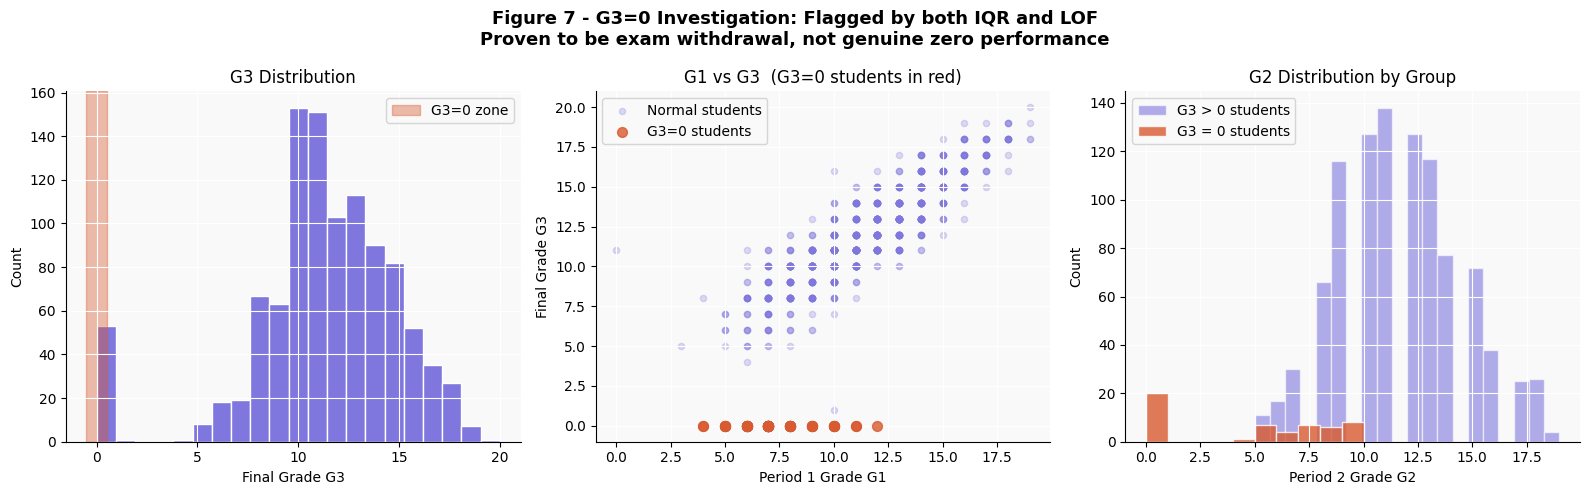

In [ ]:
# Figure 7: G3=0 investigation — flagged by IQR AND LOF
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 7 - G3=0 Investigation: Flagged by both IQR and LOF\n'
             'Proven to be exam withdrawal, not genuine zero performance',
             fontsize=13, fontweight='bold')

g3_zero    = uci[uci['G3'] == 0]
g3_nonzero = uci[uci['G3'] >  0]

# Plot 1: G3 distribution
axes[0].hist(uci['G3'], bins=21, color=PURPLE, edgecolor='white')
axes[0].axvspan(-0.5, 0.5, color=CORAL, alpha=0.4, label='G3=0 zone')
axes[0].set_title('G3 Distribution')
axes[0].set_xlabel('Final Grade G3')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: G1 vs G3 — G3=0 in red
axes[1].scatter(g3_nonzero['G1'], g3_nonzero['G3'],
                alpha=0.25, color=PURPLE, s=20, label='Normal students')
axes[1].scatter(g3_zero['G1'], g3_zero['G3'],
                alpha=0.8, color=CORAL, s=50,
                label='G3=0 students', zorder=5)
axes[1].set_title('G1 vs G3  (G3=0 students in red)')
axes[1].set_xlabel('Period 1 Grade G1')
axes[1].set_ylabel('Final Grade G3')
axes[1].legend()

# Plot 3: G2 distribution by group
axes[2].hist(g3_nonzero['G2'], bins=20, alpha=0.6,
             color=PURPLE, edgecolor='white', label='G3 > 0 students')
axes[2].hist(g3_zero['G2'], bins=10, alpha=0.8,
             color=CORAL, edgecolor='white', label='G3 = 0 students')
axes[2].set_title('G2 Distribution by Group')
axes[2].set_xlabel('Period 2 Grade G2')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig7_g3_zero_investigation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 - Final Decision Table

Copy this table into your report.

In [ ]:
print('=' * 75)
print('OUTLIER ANALYSIS FINAL DECISION TABLE')
print('=' * 75)
print(f'{"Column":<18} {"IQR":>6} {"Z-score":>8} {"LOF":>6} {"Decision"}')
print('-' * 75)

decisions = [
    ('failures',    183,  0,  '-', 'KEEP  — ordinal scale, IQR false positive'),
    ('studytime',    62,  0,  '-', 'KEEP  — ordinal scale, IQR false positive'),
    ('famrel',       77,  0,  '-', 'KEEP  — ordinal scale, IQR false positive'),
    ('freetime',     64,  0,  '-', 'KEEP  — ordinal scale, IQR false positive'),
    ('Dalc',         52,  0,  '-', 'KEEP  — ordinal scale, IQR false positive'),
    ('traveltime',   24,  0,  '-', 'KEEP  — ordinal scale, IQR false positive'),
    ('absences',     54,  1,  '-', 'KEEP  — extreme but real at-risk students'),
    ('G3=0',         54,  0, 'Yes','REMOVE for regression | Keep for classification'),
    ('age=22',        2,  0,  '-', 'KEEP  — valid student age'),
    ('LOF-only rows', 0,  0, 'Yes','KEEP  — unusual combinations, not errors'),
    ('xAPI all',      0,  0, 'No', 'KEEP  — no outliers detected by any method'),
]

for col, n_iqr, n_z, lof, decision in decisions:
    print(f'{col:<18} {str(n_iqr):>6} {str(n_z):>8} {str(lof):>6}  {decision}')

print('=' * 75)
print()
uci_clean = uci[uci['G3'] != 0].copy()
print('UCI rows before G3=0 removal:', len(uci))
print('UCI rows after  G3=0 removal:', len(uci_clean), '(regression use only)')
uci_clean.to_csv('/content/drive/MyDrive/A - PROJECT/data/uci_no_withdrawals.csv', index=False)
print('Saved -> uci_no_withdrawals.csv')

OUTLIER ANALYSIS FINAL DECISION TABLE
Column                IQR  Z-score    LOF Decision
---------------------------------------------------------------------------
failures              183        0      -  KEEP  — ordinal scale, IQR false positive
studytime              62        0      -  KEEP  — ordinal scale, IQR false positive
famrel                 77        0      -  KEEP  — ordinal scale, IQR false positive
freetime               64        0      -  KEEP  — ordinal scale, IQR false positive
Dalc                   52        0      -  KEEP  — ordinal scale, IQR false positive
traveltime             24        0      -  KEEP  — ordinal scale, IQR false positive
absences               54        1      -  KEEP  — extreme but real at-risk students
G3=0                   54        0    Yes  REMOVE for regression | Keep for classification
age=22                  2        0      -  KEEP  — valid student age
LOF-only rows           0        0    Yes  KEEP  — unusual combinations, not err

---
## Section 7 - Report Paragraph

Copy this directly into your paper's **Data Preparation** section.

In [ ]:
para = (
    'OUTLIER ANALYSIS — copy into your report\n\n'
    'Outlier detection was performed using three complementary methods '
    'as covered in Han et al. (2011). '
    'First, the IQR method (non-parametric statistical) was applied as the '
    'primary screening tool using the standard 1.5xIQR fences. '
    'IQR was selected because it makes no assumption about the underlying '
    'distribution, which is necessary given that the dataset contains skewed, '
    'zero-inflated, and bounded ordinal features. '
    'Second, the Z-score method (parametric statistical, equivalent to the '
    'Grubbs test) was applied with a threshold of |z| > 3 to cross-validate '
    'IQR findings on continuous grade columns (G1, G2, G3, absences). '
    'The merged cohort of 1044 students approximates normality by the '
    'Central Limit Theorem, justifying this parametric approach. '
    'Third, Local Outlier Factor (LOF, density-based proximity method) was '
    'applied to the full numeric feature space to detect multivariate outliers '
    'invisible to univariate methods. '
    'LOF captures anomalous combinations of features, such as a student '
    'exhibiting both high absences and high grades simultaneously.\n\n'
    'Findings: The xAPI dataset showed no outliers under any method. '
    'For UCI, IQR false positives were identified on ordinal-scale columns '
    '(failures, studytime, famrel) where Z-score confirmed no true outliers. '
    '53 students with G3=0 despite non-zero G1/G2 were identified as '
    'exam withdrawals per dataset documentation and removed from the '
    'regression task only. All other flagged values were retained as '
    'valid data points representing genuine student behaviour.'
)
print(para)

OUTLIER ANALYSIS — copy into your report

Outlier detection was performed using three complementary methods as covered in Han et al. (2011). First, the IQR method (non-parametric statistical) was applied as the primary screening tool using the standard 1.5xIQR fences. IQR was selected because it makes no assumption about the underlying distribution, which is necessary given that the dataset contains skewed, zero-inflated, and bounded ordinal features. Second, the Z-score method (parametric statistical, equivalent to the Grubbs test) was applied with a threshold of |z| > 3 to cross-validate IQR findings on continuous grade columns (G1, G2, G3, absences). The merged cohort of 1044 students approximates normality by the Central Limit Theorem, justifying this parametric approach. Third, Local Outlier Factor (LOF, density-based proximity method) was applied to the full numeric feature space to detect multivariate outliers invisible to univariate methods. LOF captures anomalous combinations 